# Smartphones in India, 2023
## Task 1 · Data preprocessing and exploratory data analysis

**T4EU Data Science Winter School, Katowice** · Team: Oleksandr Klepachevskyi, Sakthi Sivaram Manikandan

**Dataset:** [Smartphones dataset](https://www.kaggle.com/datasets/informrohit1/smartphones-dataset) on Kaggle (file `smartphones_cleaned_v6.csv`): 980 smartphones sold in India in 2023, collected from the comparison website Smartprix. Prices are in Indian rupees (₹).

**One row = one phone model.** Memory versions of the same phone (e.g. "8GB RAM + 256GB") are separate rows because they have different specs and prices.

**Our goal:** we clean and explore the data, so that it's ready for hypothesis testing (Task 2) and regression (Task 3).

| Step | What we do |
|---|---|
| 1. Data inspection | structure, size, data types, missing values, first look at outliers |
| 2. Missing data | find missing values and decide how to handle them |
| 3. Data cleaning | correct obvious errors, standardize inconsistent values, remove duplicates |
| 4. Data transformation | encode categorical variables, standardize numerical ones |
| 5. Outliers | find outliers and decide what to do with them |
| 6. Feature engineering | create new, more informative variables |
| 7. EDA | visualizations and correlation analysis |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter, StrMethodFormatter
from pathlib import Path
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA = Path("data")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# We use one chart style for the whole project (colour-blind-safe colours)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 160,
})
def box_style(color=BLUE):
    return dict(patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=color + "1A", edgecolor=color, linewidth=1.5),
                medianprops=dict(color=INK, linewidth=2),
                whiskerprops=dict(color=color, linewidth=1.5), capprops=dict(color=color, linewidth=1.5),
                flierprops=dict(marker="o", markersize=3.5, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.6))

inr = FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")    # 25000 -> "25k"
PRICE_TICKS = [5000, 10000, 20000, 50000, 100000, 200000]

def log_price_axis(ax):
    ax.set_yscale("log")
    ax.set_yticks(PRICE_TICKS)
    ax.yaxis.set_major_formatter(inr)
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

def save(fig, name):
    # We save every chart to figures/ so it can go straight into our slides
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

## Step 1 · Data inspection
We load the file and check its size, columns, data types, missing values, duplicates and the range of the numeric columns.

In [2]:
raw = pd.read_csv(DATA / "smartphones_cleaned_v6.csv")
print(f"{raw.shape[0]} phones x {raw.shape[1]} columns | brands: {raw.brand_name.nunique()}")
raw.head()

980 phones x 26 columns | brands: 46


,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height
0,oneplus,OnePlus 11 5G,54999,89.00,True,True,False,snapdragon,8.00,3.20,"5,000.00",1,100.00,12.00,256.00,6.70,120,3,1.00,android,50.00,16.00,0,NaN,1440,3216
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.00,True,False,False,snapdragon,8.00,2.20,"5,000.00",1,33.00,6.00,128.00,6.59,120,3,1.00,android,64.00,16.00,1,"1,024.00",1080,2412
2,samsung,Samsung Galaxy A14 5G,16499,75.00,True,False,False,exynos,8.00,2.40,"5,000.00",1,15.00,4.00,64.00,6.60,90,3,1.00,android,50.00,13.00,1,"1,024.00",1080,2408
3,motorola,Motorola Moto G62 5G,14999,81.00,True,False,False,snapdragon,8.00,2.20,"5,000.00",1,NaN,6.00,128.00,6.55,120,3,1.00,android,50.00,16.00,1,"1,024.00",1080,2400
4,realme,Realme 10 Pro Plus,24999,82.00,True,False,False,dimensity,8.00,2.60,"5,000.00",1,67.00,6.00,128.00,6.70,120,3,1.00,android,108.00,16.00,0,NaN,1080,2412


| Column | Type | Meaning |
|---|---|---|
| brand_name | categorical | phone brand, e.g. samsung |
| model | text | model name |
| price | numeric | price in ₹ |
| rating | numeric | Smartprix spec score (60 to 89) |
| has_5g, has_nfc, has_ir_blaster | binary | True / False |
| processor_brand | categorical | chip family, e.g. snapdragon, dimensity |
| num_cores | numeric | number of processor cores |
| processor_speed | numeric | processor speed in GHz |
| battery_capacity | numeric | battery in mAh |
| fast_charging_available | binary | 1 = supports fast charging |
| fast_charging | numeric | fast-charging power in W |
| ram_capacity | numeric | RAM in GB |
| internal_memory | numeric | storage in GB |
| screen_size | numeric | screen diagonal in inches |
| refresh_rate | numeric | screen refresh rate in Hz |
| num_rear_cameras, num_front_cameras | numeric | number of cameras |
| os | categorical | android, ios or other |
| primary_camera_rear, primary_camera_front | numeric | main camera in megapixels |
| extended_memory_available | binary | 1 = has a memory-card slot |
| extended_upto | numeric | largest supported memory card in GB |
| resolution_width, resolution_height | numeric | screen resolution in pixels |

In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   rating                     879 non-null    float64
 4   has_5g                     980 non-null    bool   
 5   has_nfc                    980 non-null    bool   
 6   has_ir_blaster             980 non-null    bool   
 7   processor_brand            960 non-null    object 
 8   num_cores                  974 non-null    float64
 9   processor_speed            938 non-null    float64
 10  battery_capacity           969 non-null    float64
 11  fast_charging_available    980 non-null    int64  
 12  fast_charging              769 non-null    float64
 13  ram_capacity               980 non-null    float64

In [4]:
raw.describe().T          # numeric columns

,count,mean,std,min,25%,50%,75%,max
price,980.00,"32,520.50","39,531.81","3,499.00","12,999.00","19,994.50","35,491.50","650,000.00"
rating,879.00,78.26,7.40,60.00,74.00,80.00,84.00,89.00
num_cores,974.00,7.77,0.84,4.00,8.00,8.00,8.00,8.00
processor_speed,938.00,2.43,0.46,1.20,2.05,2.30,2.84,3.22
battery_capacity,969.00,"4,817.75","1,009.54","1,821.00","4,500.00","5,000.00","5,000.00","22,000.00"
fast_charging_available,980.00,0.85,0.35,0.00,1.00,1.00,1.00,1.00
fast_charging,769.00,46.13,34.28,10.00,18.00,33.00,66.00,240.00
ram_capacity,980.00,6.56,2.74,1.00,4.00,6.00,8.00,18.00
internal_memory,980.00,141.04,107.13,8.00,64.00,128.00,128.00,"1,024.00"
screen_size,980.00,6.54,0.35,3.54,6.50,6.58,6.67,8.03


In [5]:
raw.describe(include=["object", "bool"]).T          # text, categorical and True/False columns

,count,unique,top,freq
brand_name,980,46,xiaomi,134
model,980,980,OnePlus 11 5G,1
has_5g,980,2,True,549
has_nfc,980,2,False,587
has_ir_blaster,980,2,False,821
processor_brand,960,13,snapdragon,413
os,966,3,android,909


In [6]:
missing = pd.DataFrame({"missing": raw.isna().sum(), "percent": (raw.isna().mean() * 100).round(1)})
print("Exact duplicate rows:", raw.duplicated().sum())
print("Rows identical to another row except for the model name:", raw.drop(columns="model").duplicated().sum())
missing[missing["missing"] > 0].sort_values("percent", ascending=False)

Exact duplicate rows: 0
Rows identical to another row except for the model name: 3


,missing,percent
extended_upto,480,49.00
fast_charging,211,21.50
rating,101,10.30
processor_speed,42,4.30
processor_brand,20,2.00
os,14,1.40
battery_capacity,11,1.10
num_cores,6,0.60
primary_camera_front,5,0.50
num_front_cameras,4,0.40


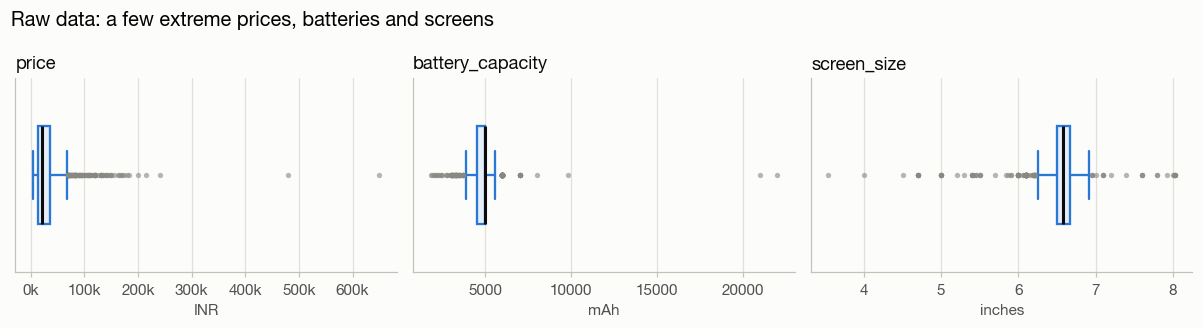

,model,price,rating
427,Vertu Signature Touch,650000,62.00
887,Xiaomi Redmi K20 Pro Signature Edition,480000,88.00
478,Huawei Mate 50 RS Porsche Design,239999,81.00
951,Huawei Mate 30 RS Porsche Design,214990,NaN
458,Xiaomi Mi Mix Alpha,199990,NaN
288,Apple iPhone 14 Pro Max (1TB),182999,78.00


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (col, unit) in zip(axes, [("price", "INR"), ("battery_capacity", "mAh"), ("screen_size", "inches")]):
    ax.boxplot(raw[col].dropna(), vert=False, **box_style())
    ax.set_title(col)
    ax.set_xlabel(unit)
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
axes[0].xaxis.set_major_formatter(inr)
fig.suptitle("Raw data: a few extreme prices, batteries and screens", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "01_raw_boxplots")
plt.show()

raw.nlargest(6, "price")[["model", "price", "rating"]]          # the most expensive phones

In [8]:
print("Processor brands:", raw.processor_brand.value_counts(dropna=False).to_dict())
print("OS:", raw.os.value_counts(dropna=False).to_dict())
print("Yes/No columns as True/False:", raw.select_dtypes("bool").columns.tolist())
print("Yes/No columns as 1/0:", ["fast_charging_available", "extended_memory_available"])
raw[raw.brand_name.isin(["redmi", "letv", "leeco"])][["brand_name", "model", "price", "processor_brand"]]

Processor brands: {'snapdragon': 413, 'helio': 201, 'dimensity': 177, 'exynos': 50, 'bionic': 45, 'unisoc': 26, 'tiger': 24, nan: 20, 'google': 9, 'kirin': 7, 'spreadtrum': 4, 'sc9863a': 2, 'fusion': 1, 'mediatek': 1}
OS: {'android': 909, 'ios': 46, nan: 14, 'other': 11}
Yes/No columns as True/False: ['has_5g', 'has_nfc', 'has_ir_blaster']
Yes/No columns as 1/0: ['fast_charging_available', 'extended_memory_available']


,brand_name,model,price,processor_brand
169,letv,Letv Y1 Pro,5499,tiger
188,leeco,LeEco S1 Pro,10999,tiger
267,redmi,Redmi Note 11 Pro 2023,18999,snapdragon
380,letv,Letv Y2 Pro,6999,unisoc
415,redmi,Redmi Note 12 Pro Speed Edition,19999,snapdragon
451,redmi,Redmi 12C,7999,helio
639,letv,Letv Y1 Pro Plus,5999,tiger


### What Step 1 tells us
- **Size:** 980 phones × 26 columns, 46 brands.
- **Data types are correct**, but yes/no information is stored in two styles: `has_5g`, `has_nfc`, `has_ir_blaster` are True/False, while `fast_charging_available` and `extended_memory_available` are 1/0 → **Steps 3 and 4**.
- **Missing values in 10 columns:** `extended_upto` 49%, `fast_charging` 21.5%, `rating` 10.3%, then `processor_speed`, `processor_brand`, `os`, `battery_capacity` and a few others below 5% → **Step 2**.
- **No exact duplicates**, but 3 phones repeat another row with a different name → **Step 3**.
- **Inconsistent labels:**
  - Chip names mix makers and product lines: "unisoc", "tiger", "spreadtrum" and "sc9863a" are all chips from the same maker, Unisoc.
  - The brand "redmi" should be "xiaomi", where all other Redmi phones are listed, and "letv" and "leeco" are the same company.
  → **Step 3**.
- **Phones that never existed:** the website also lists rumoured and concept phones with guessed specs. 27 of them were never released under that name, e.g. "Tesla Pi Phone", "Apple iPhone 14 Mini", "Samsung Galaxy Note 30 Ultra" (the Note series ended with the Note 20) and "OnePlus 11 Pro" → **Step 3**.
- **Extreme values:** prices up to ₹650,000 (a Vertu luxury phone), batteries up to 22,000 mAh (rugged phones), screens from 3.5 to 8 inches (mini phones and foldables) → **Step 5**.

## Step 2 · Handling missing data
### 2.1 How much is missing?

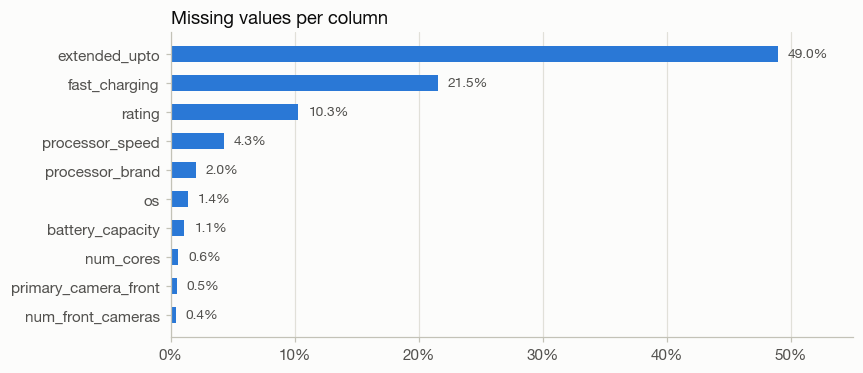

In [9]:
miss = (raw.isna().mean() * 100).loc[lambda s: s > 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(miss.index, miss.values, height=0.55, color=BLUE)
for y, v in enumerate(miss.values):
    ax.text(v + 0.8, y, f"{v:.1f}%", va="center", fontsize=9, color=INK2)
ax.set_title("Missing values per column")
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlim(0, 55)
ax.grid(axis="y", visible=False)
save(fig, "02_missing_values")
plt.show()

### 2.2 Not every empty cell means the same thing

In [10]:
fc = raw[raw.fast_charging.isna()]
print(f"fast_charging empty: {len(fc)} phones -> {(fc.fast_charging_available == 0).sum()} have NO fast charging (nothing to measure), "
      f"{(fc.fast_charging_available == 1).sum()} have fast charging but the power is unknown")

ex = raw[raw.extended_upto.isna()]
print(f"extended_upto empty: {len(ex)} phones -> {(ex.extended_memory_available == 0).sum()} have NO memory-card slot, "
      f"{(ex.extended_memory_available == 1).sum()} have a slot but the size is unknown")

print("Median price of phones with / without a rating:",
      raw.groupby(raw.rating.isna())["price"].median().rename({False: "with rating", True: "without rating"}).to_dict())
raw[raw.os.isna()][["brand_name", "model"]].head(8)

fast_charging empty: 211 phones -> 143 have NO fast charging (nothing to measure), 68 have fast charging but the power is unknown
extended_upto empty: 480 phones -> 362 have NO memory-card slot, 118 have a slot but the size is unknown
Median price of phones with / without a rating: {'with rating': 19990.0, 'without rating': 54999.0}


,brand_name,model
158,oppo,Oppo Find N2 5G
304,samsung,Samsung Galaxy Z Flip 3
320,royole,Royole FlexPai 2
363,oppo,OPPO Find N Flip
389,oppo,OPPO Find N2 Flip
498,samsung,Samsung Galaxy Z Flip 4 5G
561,lg,LG Wing 5G
599,oukitel,Oukitel WP21


### 2.3 Decision

| Column | Missing | Decision | Why |
|---|---|---|---|
| `extended_upto` | 49% | **remove the column** | Half of it is empty. Whether a phone has a memory-card slot is already in `extended_memory_available`. |
| `fast_charging` | 21.5% | no fast charging → **0 W**; unknown power → **median of the same brand** | The two kinds of empty cells mean different things. |
| `rating` | 10.3% | **median rating of phones in the same price group** (4 groups) | Ratings are missing mostly for expensive phones, so the overall median would underrate them. |
| `processor_speed` | 4.3% | **median of the same processor brand** | Chips of the same family have similar speeds. |
| `processor_brand` | 2.0% | **"unknown"** | It can't be guessed reliably. |
| `os` | 1.4% | **from the brand**: Huawei → other, all others → android | They are foldables and Android phones; Huawei phones use their own system (listed as "other" in this data). |
| `battery_capacity` | 1.1% | **median of the same brand** | |
| `num_cores`, `num_front_cameras` | < 1% | **most common value** | |
| `primary_camera_front` | < 1% | **median** | |

We add flag columns (`rating_imputed`, `processor_speed_imputed`, `fast_charging_imputed`) that mark the filled-in values, so that in Tasks 2 and 3 we can check our results without them.

In [11]:
df = raw.copy()

def impute_median(data, col, groups):
    # We fill a missing value with the median of its group; if the group has no data, we use the overall median
    filled = data[col].copy()
    for group in groups:
        filled = filled.fillna(data.groupby(group, observed=True)[col].transform("median"))
    return filled.fillna(data[col].median())

# We remove the column with excessive missing values
df = df.drop(columns="extended_upto")

# Flags first, so we remember which values were filled in
df["rating_imputed"] = df["rating"].isna()
df["processor_speed_imputed"] = df["processor_speed"].isna()
df["fast_charging_imputed"] = df["fast_charging"].isna() & (df["fast_charging_available"] == 1)

price_group = pd.qcut(df["price"], 4)          # 4 price groups with the same number of phones
df["rating"] = impute_median(df.assign(price_group=price_group), "rating", ["price_group"])
df["processor_speed"] = impute_median(df, "processor_speed", ["processor_brand"])
df["battery_capacity"] = impute_median(df, "battery_capacity", ["brand_name"])

# fast_charging: unknown power -> brand median; no fast charging at all -> 0 W
has_fast = df["fast_charging_available"] == 1
df.loc[has_fast, "fast_charging"] = impute_median(df[has_fast], "fast_charging", ["brand_name"])
df.loc[~has_fast, "fast_charging"] = 0

df["processor_brand"] = df["processor_brand"].fillna("unknown")
df["os"] = df["os"].fillna(df["brand_name"].map(lambda b: "other" if b == "huawei" else "android"))
for col in ["num_cores", "num_front_cameras"]:
    df[col] = df[col].fillna(df[col].mode()[0])
df["primary_camera_front"] = df["primary_camera_front"].fillna(df["primary_camera_front"].median())

print("Missing values left:", int(df.isna().sum().sum()))
pd.DataFrame({"filled in": [df.rating_imputed.sum(), df.processor_speed_imputed.sum(), df.fast_charging_imputed.sum()],
              "median before": [raw.rating.median(), raw.processor_speed.median(), raw.fast_charging.median()],
              "median after": [df.rating.median(), df.processor_speed.median(), df.loc[has_fast, "fast_charging"].median()]},
             index=["rating", "processor_speed", "fast_charging (phones with fast charging)"])

Missing values left: 0


,filled in,median before,median after
rating,101,80.00,80.00
processor_speed,42,2.30,2.36
fast_charging (phones with fast charging),68,33.00,33.00


## Step 3 · Data cleaning
### 3.1 Correct obvious errors
**27 phones in the data never existed** under that name: rumours, concepts, code names and cancelled phones that the website listed with guessed specs. Their numbers are invented, so we remove them. The reason for each phone is in the table. We also check that no value is impossible (negative, zero, or far outside what phones have).

In [12]:
never_released = {      # model: why it never existed
    "Tesla Pi Phone": "concept, never made",
    "Apple iPhone 7s": "rumour (Apple went from 7 to 8)",
    "Apple iPhone 9": "rumour (Apple went from 8 to X)",
    "Apple iPhone XR2": "rumour (the XR was followed by the iPhone 11)",
    "Apple iPhone 14 Mini": "rumour (the 14 series had a Plus, no Mini)",
    "Apple iPhone 15 Ultra": "rumour (released as the 15 Pro Max)",
    "Apple iPhone SE 4": "rumour (never released under this name)",
    "Samsung Galaxy Note 30 Ultra 5G": "rumour (the Note series ended with the Note 20)",
    "Samsung Galaxy A74 5G": "rumour", "Samsung Galaxy A75 5G": "rumour",
    "Samsung Galaxy A83 5G": "rumour", "Samsung Galaxy A92 5G": "rumour",
    "OnePlus 9T": "cancelled",
    "OnePlus 11 Pro": "rumour (only the OnePlus 11 was released)", "OnePlus 12 Pro": "rumour",
    "OnePlus Z": "code name (released as the OnePlus Nord)",
    "OnePlus Clover": "code name (released as the Nord N100)",
    "OnePlus Nord Lite": "rumour", "OnePlus Nord 2 Lite 5G": "rumour (released as the Nord CE 2 Lite)",
    "Xiaomi 12 Ultra 5G": "cancelled (Xiaomi released the 12S Ultra instead)",
    "Xiaomi Mi Mix Alpha": "concept, never sold", "OPPO X 2021": "concept, never sold",
    "Nothing Phone 1 Lite": "rumour", "Nokia N73 5G": "rumour", "Nokia X60 5G": "rumour",
    "Nokia X60 Pro 5G": "rumour", "Jio JioPhone 5G": "rumour, never launched",
}
fake = df["model"].isin(never_released)
display(df[fake][["model", "price"]].assign(reason=df["model"].map(never_released)).sort_values("model"))
df = df[~fake]
print(f"Removed {fake.sum()} phones that were never released | phones left: {len(df)}")

numeric = df.select_dtypes("number")
print("Columns with zero or negative values:", [c for c in numeric if (numeric[c] <= 0).any() and c not in
      ["fast_charging", "fast_charging_available", "extended_memory_available"]])
df[["price", "rating", "processor_speed", "battery_capacity", "ram_capacity", "internal_memory", "screen_size", "refresh_rate"]].agg(["min", "max"])

,model,price,reason
280,Apple iPhone 14 Mini,69990,"rumour (the 14 series had a Plus, no Mini)"
398,Apple iPhone 15 Ultra,149900,rumour (released as the 15 Pro Max)
595,Apple iPhone 7s,52990,rumour (Apple went from 7 to 8)
173,Apple iPhone 9,29990,rumour (Apple went from 8 to X)
737,Apple iPhone SE 4,49990,rumour (never released under this name)
262,Apple iPhone XR2,71999,rumour (the XR was followed by the iPhone 11)
52,Jio JioPhone 5G,11990,"rumour, never launched"
192,Nokia N73 5G,46999,rumour
926,Nokia X60 5G,39990,rumour
542,Nokia X60 Pro 5G,49990,rumour


Removed 27 phones that were never released | phones left: 953
Columns with zero or negative values: []


,price,rating,processor_speed,battery_capacity,ram_capacity,internal_memory,screen_size,refresh_rate
min,3499,60.00,1.20,"1,821.00",1.00,8.00,3.54,60
max,650000,89.00,3.22,"22,000.00",18.00,"1,024.00",8.03,240


All ranges are possible for real phones (we handle the extreme ones in Step 5). The only zeros are in `fast_charging`, where we set 0 W on purpose in Step 2.

### 3.2 Standardize inconsistent values

In [13]:
# Chip names: Tiger, Spreadtrum and SC9863A are all chips made by Unisoc
df["processor_brand"] = df["processor_brand"].replace({"tiger": "unisoc", "spreadtrum": "unisoc", "sc9863a": "unisoc"})

# Brand names: Redmi phones are listed under xiaomi everywhere else; LeTV renamed itself LeEco
df["brand_name"] = df["brand_name"].replace({"redmi": "xiaomi", "letv": "leeco"})

# Yes/No columns: two use 1/0, three use True/False -> the same True/False format for all five
for col in ["fast_charging_available", "extended_memory_available"]:
    df[col] = df[col].astype(bool)

print("Processor brands:", df.processor_brand.value_counts().to_dict())
print("Brands:", df.brand_name.nunique(), "| yes/no columns:", [c for c in df.select_dtypes("bool") if not c.endswith("_imputed")])

Processor brands: {'snapdragon': 394, 'helio': 201, 'dimensity': 176, 'unisoc': 56, 'exynos': 50, 'bionic': 40, 'unknown': 19, 'google': 9, 'kirin': 7, 'mediatek': 1}
Brands: 43 | yes/no columns: ['has_5g', 'has_nfc', 'has_ir_blaster', 'fast_charging_available', 'extended_memory_available']


### 3.3 Remove duplicates
There are no exact duplicates. But 3 phones are **identical to another row in every column except the name**: the same phone sold under two names, or a special edition with the same specs and price. We keep one of each, the one with the shorter (standard) name.

Memory versions like "Samsung Galaxy A13 (4GB RAM + 128GB)" are **not** duplicates: their RAM, storage and price differ.

In [14]:
same_specs = df.drop(columns="model").duplicated(keep=False)
display(df[same_specs][["model", "price", "ram_capacity", "internal_memory", "processor_brand"]].sort_values("price"))

# We keep the shorter (standard) name of each pair, e.g. "OPPO Reno 8 Pro 5G" rather than its "House of Dragon Edition"
before = len(df)
df = (df.assign(name_length=df["model"].str.len())
        .sort_values("name_length", kind="stable")
        .drop_duplicates(subset=[c for c in df.columns if c != "model"])
        .sort_index()
        .drop(columns="name_length")
        .reset_index(drop=True))
print(f"Removed {before - len(df)} duplicates | phones left: {len(df)}")
print("Memory versions (kept):", df.model.str.contains(r"\(\d+\s?GB RAM", case=False).sum())

,model,price,ram_capacity,internal_memory,processor_brand
504,Vivo Y15s,8499,3.00,32.00,helio
746,Vivo Y15C,8499,3.00,32.00,helio
648,Xiaomi Redmi Note 11E 5G,13990,4.00,128.00,dimensity
806,Xiaomi Redmi 10 Prime Plus 5G,13990,4.00,128.00,dimensity
195,OPPO Reno 8 Pro House of Dragon Edition,45999,12.00,256.00,dimensity
228,OPPO Reno 8 Pro 5G,45999,12.00,256.00,dimensity


Removed 3 duplicates | phones left: 950
Memory versions (kept): 221


## Step 4 · Data transformation
### 4.1 Encode categorical variables
- We use **label encoding** for the five yes/no columns: True = 1, False = 0.
- We use **one-hot encoding** for `os` (3 values) and `processor_brand` (10 values): one 0/1 column per value. A regression model can't use text, and numbering these categories (1, 2, 3…) would invent an order that doesn't exist.

In [15]:
yes_no = ["has_5g", "has_nfc", "has_ir_blaster", "fast_charging_available", "extended_memory_available"]
df[yes_no] = df[yes_no].astype(int)

dummies = pd.get_dummies(df[["os", "processor_brand"]], prefix=["os", "chip"], dtype=int)
df = pd.concat([df, dummies], axis=1)
print("New one-hot columns:", dummies.columns.tolist())
df[["model", "has_5g", "has_nfc", "os", "os_android", "os_ios", "os_other", "processor_brand", "chip_snapdragon", "chip_dimensity"]].head(5)

New one-hot columns: ['os_android', 'os_ios', 'os_other', 'chip_bionic', 'chip_dimensity', 'chip_exynos', 'chip_google', 'chip_helio', 'chip_kirin', 'chip_mediatek', 'chip_snapdragon', 'chip_unisoc', 'chip_unknown']


,model,has_5g,has_nfc,os,os_android,os_ios,os_other,processor_brand,chip_snapdragon,chip_dimensity
0,OnePlus 11 5G,1,1,android,1,0,0,snapdragon,1,0
1,OnePlus Nord CE 2 Lite 5G,1,0,android,1,0,0,snapdragon,1,0
2,Samsung Galaxy A14 5G,1,0,android,1,0,0,exynos,0,0
3,Motorola Moto G62 5G,1,0,android,1,0,0,snapdragon,1,0
4,Realme 10 Pro Plus,1,0,android,1,0,0,dimensity,0,1


### 4.2 z-scores (standardizing the numerical features)
The **z-score** of a value is **z = (x − mean) / standard deviation**: how many standard deviations the value is above (+) or below (−) the mean. After this, every variable has mean 0 and standard deviation 1, so rupees, gigabytes and inches become comparable. We add a `_z` column for each of the 10 numeric variables (e.g. `price_z`) and keep the originals, because Tasks 2 and 3 need real units (e.g. "₹ per GB of RAM").

In [16]:
to_scale = ["price", "rating", "processor_speed", "battery_capacity", "fast_charging", "ram_capacity",
            "internal_memory", "screen_size", "refresh_rate", "primary_camera_rear"]
z_cols = [f"{c}_z" for c in to_scale]
df[z_cols] = StandardScaler().fit_transform(df[to_scale])

print("z-scores of the first phones:")
display(df[["model"] + z_cols[:5]].head(3).round(2))

# We check that every z-score column has mean 0 and standard deviation 1
z_summary = pd.DataFrame({"mean of z": df[z_cols].mean().values, "std of z": df[z_cols].std(ddof=0).values,
                          "min z": df[z_cols].min().values, "max z": df[z_cols].max().values}, index=to_scale)
z_summary.round(2) + 0.0

z-scores of the first phones:


,model,price_z,rating_z,processor_speed_z,battery_capacity_z,fast_charging_z
0,OnePlus 11 5G,0.59,1.43,1.67,0.19,1.79
1,OnePlus Nord CE 2 Lite 5G,-0.30,0.35,-0.49,0.19,-0.14
2,Samsung Galaxy A14 5G,-0.39,-0.46,-0.06,0.19,-0.66


,mean of z,std of z,min z,max z
price,0.00,1.00,-0.72,15.78
rating,0.00,1.00,-2.48,1.43
processor_speed,0.00,1.00,-2.65,1.71
battery_capacity,0.00,1.00,-2.94,16.90
fast_charging,0.00,1.00,-1.10,5.83
ram_capacity,0.00,1.00,-2.03,4.22
internal_memory,0.00,1.00,-1.24,8.28
screen_size,0.00,1.00,-8.90,4.43
refresh_rate,0.00,1.00,-1.11,5.13
primary_camera_rear,0.00,1.00,-1.51,4.76


## Step 5 · Handling outliers
We check the 10 numeric variables from Step 4 with the two methods from the course, compare them, and look at the boxplots before deciding what to do.

### 5.1 Detecting outliers using z-scores
A value is a potential outlier if **|z| > 3**: more than 3 standard deviations away from the mean.

In [17]:
Z_THRESHOLD = 3
outlier_vars = to_scale                       # the 10 numeric variables standardized in Step 4

z_flags = pd.DataFrame({col: df[f"{col}_z"].abs() > Z_THRESHOLD for col in outlier_vars})
pd.DataFrame({"potential outliers": z_flags.sum(), "percent": (z_flags.mean() * 100).round(1)})

,potential outliers,percent
price,13,1.40
rating,0,0.00
processor_speed,0,0.00
battery_capacity,4,0.40
fast_charging,12,1.30
ram_capacity,10,1.10
internal_memory,25,2.60
screen_size,34,3.60
refresh_rate,1,0.10
primary_camera_rear,14,1.50


In [18]:
# The 3 most extreme phones of each variable
rows = []
for col in outlier_vars:
    flagged = df.loc[z_flags[col], ["model", col, f"{col}_z"]]
    top = flagged.reindex(flagged[f"{col}_z"].abs().sort_values(ascending=False).index).head(3)
    rows += [{"variable": col, "model": m, "value": v, "z-score": round(z, 2)} for m, v, z in top.itertuples(index=False)]
pd.DataFrame(rows)

,variable,model,value,z-score
0,price,Vertu Signature Touch,"650,000.00",15.78
1,price,Xiaomi Redmi K20 Pro Signature Edition,"480,000.00",11.44
2,price,Huawei Mate 50 RS Porsche Design,"239,999.00",5.31
3,battery_capacity,Doogee V Max,"22,000.00",16.90
4,battery_capacity,Oukitel WP19,"21,000.00",15.92
5,battery_capacity,Oukitel WP21,"9,800.00",4.91
6,fast_charging,Realme GT Neo 5,240.00,5.83
7,fast_charging,Xiaomi Redmi Note 12 Pro Max 5G,210.00,4.96
8,fast_charging,Xiaomi Redmi Note 12 Discovery Edition,210.00,4.96
9,ram_capacity,Asus ROG Phone 6 Pro 5G,18.00,4.22


### 5.2 Detecting outliers using the IQR method
A value is a potential outlier if it is **below Q1 − 1.5·IQR or above Q3 + 1.5·IQR**, where IQR = Q3 − Q1.

In [19]:
iqr_flags = pd.DataFrame(index=df.index)
rows = []
for col in outlier_vars:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_flags[col] = (df[col] < lower) | (df[col] > upper)
    rows.append({"variable": col, "Q1": q1, "Q3": q3, "IQR": iqr, "lower bound": lower, "upper bound": upper,
                 "potential outliers": iqr_flags[col].sum(), "percent": round(iqr_flags[col].mean() * 100, 1)})
pd.DataFrame(rows).set_index("variable")

,Q1,Q3,IQR,lower bound,upper bound,potential outliers,percent
variable,,,,,,,
price,"12,999.00","34,990.00","21,991.00","-19,987.50","67,976.50",98,10.30
rating,74.00,85.00,11.00,57.50,101.50,0,0.00
processor_speed,2.05,2.84,0.79,0.86,4.03,0,0.00
battery_capacity,"4,500.00","5,000.00",500.00,"3,750.00","5,750.00",131,13.80
fast_charging,18.00,65.00,47.00,-52.50,135.50,12,1.30
ram_capacity,4.00,8.00,4.00,-2.00,14.00,10,1.10
internal_memory,64.00,128.00,64.00,-32.00,224.00,176,18.50
screen_size,6.50,6.67,0.17,6.25,6.92,106,11.20
refresh_rate,60.00,120.00,60.00,-30.00,210.00,1,0.10


### 5.3 Comparing the two methods

In [20]:
comparison = pd.DataFrame({"z-score outliers": z_flags.sum(), "IQR outliers": iqr_flags.sum()})
comparison["difference (z - IQR)"] = comparison["z-score outliers"] - comparison["IQR outliers"]
comparison["flagged by both"] = (z_flags & iqr_flags).sum()
comparison

,z-score outliers,IQR outliers,difference (z - IQR),flagged by both
price,13,98,-85,13
rating,0,0,0,0
processor_speed,0,0,0,0
battery_capacity,4,131,-127,4
fast_charging,12,12,0,12
ram_capacity,10,10,0,10
internal_memory,25,176,-151,25
screen_size,34,106,-72,34
refresh_rate,1,1,0,1
primary_camera_rear,14,14,0,14


**What the comparison shows**
- **The IQR method flags many more phones for some variables.** For example: price 98 vs 13, battery 131 vs 4, storage 176 vs 25, screen size 106 vs 34.
- **Every z-score outlier is also an IQR outlier** ("flagged by both" equals the z-score column). The z-score method only finds the most extreme part of the IQR outliers.
- **Why are they so different?**
  - The **IQR method** looks only at the middle half of the data. When most phones have the same value, the IQR is tiny. For battery, Q1 = 4,500 and Q3 = 5,000 mAh, so ordinary iPhones with 3,000–4,000 mAh fall below the lower fence. For storage, Q1 = 64 and Q3 = 128 GB, so every phone with 256 GB or more counts as an outlier.
  - The **z-score method** uses the mean and the standard deviation, and the extreme phones themselves pull both of them up (e.g. the 22,000 mAh battery), so only the most extreme phones reach |z| > 3. It also assumes a roughly bell-shaped distribution, which price and battery are not (both are strongly skewed, see the boxplots below).
- For 6 of the 10 variables (rating, processor speed, fast charging, RAM, refresh rate, rear camera), both methods agree.
- **Conclusion:** neither rule should be applied blindly. We use them to find candidates, and then look at who the phones are (5.5) before deciding.

### 5.4 Box-and-whisker diagrams
The dots beyond the whiskers are exactly the IQR outliers from 5.2.

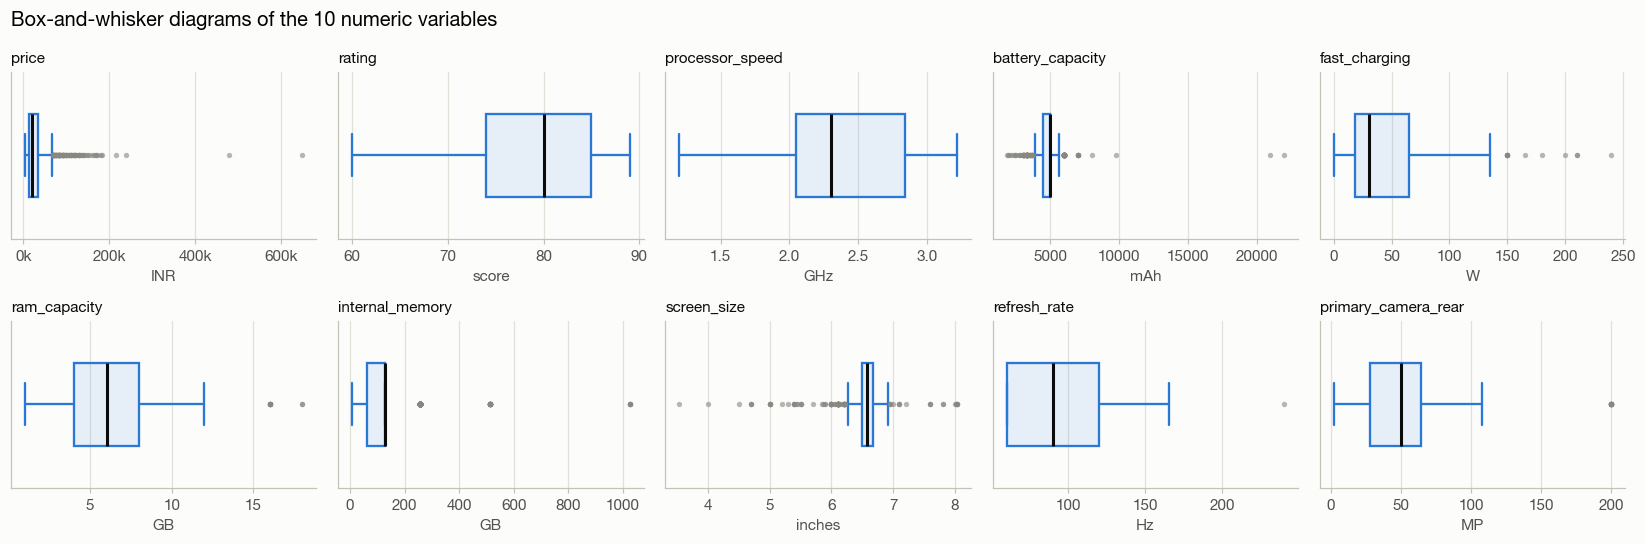

In [21]:
units = {"price": "INR", "rating": "score", "processor_speed": "GHz", "battery_capacity": "mAh",
         "fast_charging": "W", "ram_capacity": "GB", "internal_memory": "GB", "screen_size": "inches",
         "refresh_rate": "Hz", "primary_camera_rear": "MP"}
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for ax, col in zip(axes.flat, outlier_vars):
    ax.boxplot(df[col], vert=False, **box_style())
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(units[col])
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
axes.flat[0].xaxis.set_major_formatter(inr)
fig.suptitle("Box-and-whisker diagrams of the 10 numeric variables", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "03_boxplots_numeric")
plt.show()

### 5.5 Who are these outliers?
- **Battery:** most phones have exactly 5,000 mAh, so the IQR is tiny and the rule flags every iPhone and every phone with a slightly bigger battery. These are normal phones, so the IQR rule doesn't fit this variable.
- **Screen:** compact phones and foldables.
- **Price:** flagships, plus a few **luxury editions** whose price comes from gold, leather or a fashion brand, not from the specs:

In [22]:
luxury = df["model"].str.contains("Vertu|Signature Edition|Porsche Design")
display(df[luxury][["model", "price", "rating", "ram_capacity", "internal_memory"]])
print("For comparison, the median flagship (price >= 60,000):", f"{df.loc[df.price >= 60000, 'price'].median():,.0f}")
print("Biggest batteries:", df.nlargest(3, "battery_capacity")[["model", "battery_capacity"]].values.tolist())

,model,price,rating,ram_capacity,internal_memory
414,Vertu Signature Touch,650000,62.00,2.00,64.00
464,Huawei Mate 50 RS Porsche Design,239999,81.00,12.00,512.00
860,Xiaomi Redmi K20 Pro Signature Edition,480000,88.00,8.00,256.00
921,Huawei Mate 30 RS Porsche Design,214990,86.00,12.00,512.00


For comparison, the median flagship (price >= 60,000): 91,999
Biggest batteries: [['Doogee V Max', 22000.0], ['Oukitel WP19', 21000.0], ['Oukitel WP21', 9800.0]]


### 5.6 Decision
- **We remove the 4 luxury editions.** They are not typical phones: their price doesn't depend on RAM, chip or camera, so they would distort our price regression in Task 3.
- **We keep all other extreme phones** (flagships, foldables, rugged phones with huge batteries, mini phones). They are real, and removing them would bias our results.
- **Transformation:** price is very right-skewed (a long tail of expensive phones). **log(price)** makes it almost symmetric, which suits linear regression better, so we add it as a new column `log_price`.
- **Flag:** we mark the phones with |z| > 3 in price, battery or screen size in the column `is_outlier`, so that in Task 3 we can check our results without them.
- After removing rows, we **recompute the standardized columns** from Step 4.

Phones left: 946 | flagged as outliers (kept): 59
Skewness of price: 2.39 -> log(price): 0.51


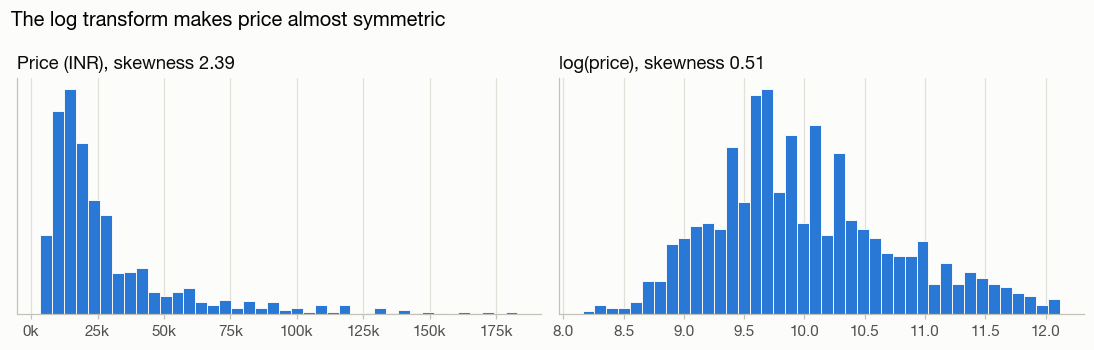

In [23]:
df = df[~luxury].reset_index(drop=True)
df["log_price"] = np.log(df["price"])
df[z_cols] = StandardScaler().fit_transform(df[to_scale])
df["is_outlier"] = (df[["price_z", "battery_capacity_z", "screen_size_z"]].abs() > 3).any(axis=1)

print(f"Phones left: {len(df)} | flagged as outliers (kept): {df.is_outlier.sum()}")
print(f"Skewness of price: {df.price.skew():.2f} -> log(price): {df.log_price.skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(df["price"], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
axes[0].set_title(f"Price (INR), skewness {df.price.skew():.2f}")
axes[0].xaxis.set_major_formatter(inr)
axes[1].hist(df["log_price"], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
axes[1].set_title(f"log(price), skewness {df.log_price.skew():.2f}")
for ax in axes:
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
fig.suptitle("The log transform makes price almost symmetric", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "04_price_log_transform")
plt.show()

## Step 6 · Feature engineering

| New feature | How it's made | Why it's useful |
|---|---|---|
| `price_eur` | price / 90 (approximate 2023 exchange rate) | easier to understand in Europe |
| `price_segment` | Budget < ₹15k, Mid-range ₹15–30k, Premium ₹30–60k, Flagship ≥ ₹60k | a categorical variable for chi-square tests |
| `chip_maker` | Snapdragon → Qualcomm, Helio and Dimensity → MediaTek, Bionic → Apple, … | one clean category per chip manufacturer |
| `ppi` | √(width² + height²) / screen size | pixel density: screen sharpness in one number |
| `total_cameras` | rear + front cameras | camera setup in one number |
| `is_foldable` | "Yes" if the model is a Fold or Flip phone | a special phone type |
| `has_5g_label` | "Yes" / "No" | the outcome for logistic regression in Task 3 |

In [24]:
df["price_eur"] = (df["price"] / 90).round(0)
df["price_segment"] = pd.cut(df["price"], bins=[0, 14999, 29999, 59999, np.inf],
                             labels=["Budget", "Mid-range", "Premium", "Flagship"])
df["chip_maker"] = df["processor_brand"].map({
    "snapdragon": "Qualcomm", "dimensity": "MediaTek", "helio": "MediaTek", "mediatek": "MediaTek",
    "exynos": "Samsung", "bionic": "Apple", "unisoc": "Unisoc", "google": "Google", "kirin": "Huawei",
    "unknown": "Unknown"})
df["ppi"] = (np.sqrt(df["resolution_width"] ** 2 + df["resolution_height"] ** 2) / df["screen_size"]).round(0)
df["total_cameras"] = df["num_rear_cameras"] + df["num_front_cameras"]
df["is_foldable"] = np.where(df["model"].str.contains(r"Fold|Flip|FlexPai|Mate X", case=False), "Yes", "No")
df["has_5g_label"] = np.where(df["has_5g"] == 1, "Yes", "No")
df["ppi_z"] = StandardScaler().fit_transform(df[["ppi"]]).ravel()

print("Price segments:", df.price_segment.value_counts().sort_index().to_dict())
print("Chip makers:", df.chip_maker.value_counts().to_dict())
print("Foldables:", (df.is_foldable == "Yes").sum())

Price segments: {'Budget': 332, 'Mid-range': 345, 'Premium': 162, 'Flagship': 107}
Chip makers: {'Qualcomm': 391, 'MediaTek': 375, 'Unisoc': 56, 'Samsung': 50, 'Apple': 40, 'Unknown': 19, 'Google': 9, 'Huawei': 6}
Foldables: 19


**Are the new features informative?** Share of 5G phones and median price by group:

In [25]:
pd.concat({"price_segment": df.groupby("price_segment", observed=True).agg(phones=("model", "size"),
                                                                           share_5g=("has_5g", "mean"),
                                                                           median_price=("price", "median")),
           "chip_maker": df.groupby("chip_maker").agg(phones=("model", "size"), share_5g=("has_5g", "mean"),
                                                      median_price=("price", "median"))
                           .sort_values("phones", ascending=False)}).style.format({"share_5g": "{:.0%}", "median_price": "{:,.0f}"})

## Step 7 · Exploratory data analysis
### 7.1 Descriptive statistics of the clean data
**Numerical variables**

In [26]:
def describe_in_detail(data, columns):
    rows = []
    for col in columns:
        s = data[col]
        modes = s.mode()
        q1, median, q3 = s.quantile([0.25, 0.50, 0.75])
        rows.append({"variable": col, "mean": s.mean(), "median (Q2)": median,
                     "mode": modes.iloc[0] if len(modes) == 1 else ", ".join(f"{m:g}" for m in modes),
                     "min": s.min(), "Q1": q1, "Q3": q3, "max": s.max(), "range": s.max() - s.min(),
                     "IQR": q3 - q1, "variance": s.var(), "std": s.std(),
                     "skewness": s.skew(), "kurtosis": s.kurt()})
    return pd.DataFrame(rows).set_index("variable")

describe_in_detail(df, to_scale)

,mean,median (Q2),mode,min,Q1,Q3,max,range,IQR,variance,std,skewness,kurtosis
variable,,,,,,,,,,,,,
price,"30,219.71","19,990.00","14,999.00","3,499.00","12,999.00","34,979.75","182,999.00","179,500.00","21,980.75","842,563,483.54","29,026.94",2.39,6.38
rating,78.39,80.00,86.00,60.00,74.00,84.75,89.00,29.00,10.75,55.03,7.42,-0.65,-0.48
processor_speed,2.43,2.30,2.00,1.20,2.05,2.84,3.22,2.02,0.79,0.21,0.46,0.21,-0.63
battery_capacity,"4,812.29","5,000.00","5,000.00","1,821.00","4,500.00","5,000.00","22,000.00","20,179.00",500.00,"1,032,350.64","1,016.05",9.34,154.53
fast_charging,37.96,30.00,33.00,0.00,18.00,65.00,240.00,240.00,47.00,"1,205.41",34.72,1.60,3.48
ram_capacity,6.52,6.00,8.00,1.00,4.00,8.00,18.00,17.00,4.00,7.33,2.71,0.75,1.10
internal_memory,139.58,128.00,128.00,8.00,64.00,128.00,"1,024.00","1,016.00",64.00,"11,136.40",105.53,4.01,26.62
screen_size,6.54,6.58,6.50,3.54,6.50,6.67,8.03,4.49,0.17,0.11,0.33,-2.09,19.43
refresh_rate,92.09,90.00,60.00,60.00,60.00,120.00,240.00,180.00,60.00,831.49,28.84,0.30,-0.63


**What the statistics tell us**
- **Price:** the mean (₹30,220) is much higher than the median (₹19,990) because expensive phones pull it up (skewness 2.39). The median describes a typical phone better. The most common price (mode) is ₹14,999.
- **Battery:** the median and the mode are both 5,000 mAh. The huge range (1,821–22,000) and the very high kurtosis (154.5) come from just 3 rugged phones.
- **Rating and processor speed** are almost symmetric (skewness −0.65 and 0.21).
- **Screen size** is very concentrated (IQR only 0.17 inches), with a tail of small phones (skewness −2.09).

**Frequency tables for categorical variables**

In [27]:
def yes_no(series):
    # We show 1/0 columns as Yes/No in the tables
    return series.map({1: "Yes", 0: "No"}) if set(series.unique()) <= {0, 1} else series

categorical = ["has_5g", "has_nfc", "has_ir_blaster", "fast_charging_available", "extended_memory_available",
               "os", "price_segment", "chip_maker", "processor_brand", "brand_name"]
for col in categorical:
    counts = yes_no(df[col]).value_counts(sort=col != "price_segment")
    table = pd.DataFrame({"frequency": counts, "percent": (counts / len(df) * 100).round(1)})
    print(f"\n{col}" + (f" (top 10 of {len(table)})" if col == "brand_name" else ""))
    display(table.head(10))


has_5g


,frequency,percent
has_5g,,
Yes,527,55.70
No,419,44.30



has_nfc


,frequency,percent
has_nfc,,
No,574,60.70
Yes,372,39.30



has_ir_blaster


...

,frequency,percent
chip_maker,,
Qualcomm,391,41.30
MediaTek,375,39.60
Unisoc,56,5.90
Samsung,50,5.30
Apple,40,4.20
Unknown,19,2.00
Google,9,1.00
Huawei,6,0.60



processor_brand


,frequency,percent
processor_brand,,
snapdragon,391,41.30
helio,200,21.10
dimensity,174,18.40
unisoc,56,5.90
exynos,50,5.30
bionic,40,4.20
unknown,19,2.00
google,9,1.00
kirin,6,0.60



brand_name (top 10 of 42)


,frequency,percent
brand_name,,
xiaomi,133,14.10
samsung,127,13.40
vivo,110,11.60
realme,97,10.30
oppo,86,9.10
motorola,52,5.50
poco,41,4.30
apple,40,4.20
oneplus,35,3.70


**Cross tabulations (crosstabs):** frequencies, % of all phones, and % within each row

In [28]:
pairs = [("price_segment", "has_5g"), ("chip_maker", "has_5g"), ("os", "has_nfc")]
for row_var, col_var in pairs:
    row_values, col_values = yes_no(df[row_var]), yes_no(df[col_var])
    tables = {"frequency": pd.crosstab(row_values, col_values),
              "% of all phones": pd.crosstab(row_values, col_values, normalize="all").mul(100).round(1),
              "% of the row": pd.crosstab(row_values, col_values, normalize="index").mul(100).round(1)}
    print(f"\n{row_var} x {col_var}")
    display(pd.concat(tables, axis=1))


price_segment x has_5g


frequency      % of all phones       % of the row      
has_5g               No  Yes              No   Yes           No   Yes
price_segment                                                        
Budget              289   43           30.50  4.50        87.00 13.00
Mid-range           112  233           11.80 24.60        32.50 67.50
Premium              11  151            1.20 16.00         6.80 93.20
Flagship              7  100            0.70 10.60         6.50 93.50


chip_maker x has_5g


frequency      % of all phones       % of the row       
has_5g            No  Yes              No   Yes           No    Yes
chip_maker                                                         
Apple              5   35            0.50  3.70        12.50  87.50
Google             0    9            0.00  1.00         0.00 100.00
Huawei             3    3            0.30  0.30        50.00  50.00
MediaTek         201  174           21.20 18.40        53.60  46.40
Qualcomm         113  278           11.90 29.40        28.90  71.10
Samsung           25   25            2.60  2.60        50.00  50.00
Unisoc            56    0            5.90  0.00       100.00   0.00
Unknown           16    3            1.70  0.30        84.20  15.80


os x has_nfc


frequency      % of all phones       % of the row       
has_nfc        No  Yes              No   Yes           No    Yes
os                                                              
android       571  324           60.40 34.20        63.80  36.20
ios             0   40            0.00  4.20         0.00 100.00
other           3    8            0.30  0.80        27.30  72.70

**What the crosstabs show**
- **Price segment × 5G:** only 13.0% of Budget phones have 5G, against 93.2% of Premium and 93.5% of Flagship phones. That is a strong relationship.
- **Chip maker × 5G:** all Unisoc phones are 4G only and all Google phones are 5G. MediaTek is split (46.4% 5G) because it makes both Helio (4G) and Dimensity (5G) chips.
- **OS × NFC:** every iPhone has NFC, against 36.2% of Android phones.
- Some groups are small (Google 9 phones, Huawei 6). For a chi-square test, small groups should be combined so that every expected count is at least 5.

### 7.2 Visualizations
**a) Which brands are in the data?**

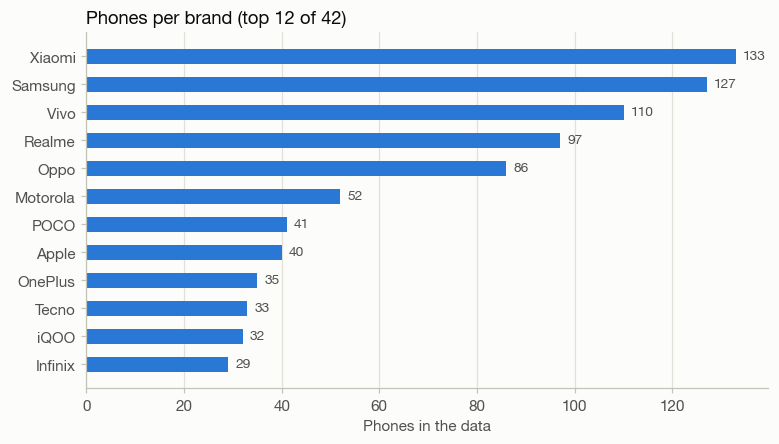

In [29]:
top_brands = df["brand_name"].value_counts().head(12).sort_values()
names = {"oneplus": "OnePlus", "iqoo": "iQOO", "poco": "POCO"}

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh([names.get(b, b.title()) for b in top_brands.index], top_brands.values, height=0.55, color=BLUE)
for y, v in enumerate(top_brands.values):
    ax.text(v + 1.5, y, str(v), va="center", fontsize=9, color=INK2)
ax.set_title(f"Phones per brand (top 12 of {df.brand_name.nunique()})")
ax.set_xlabel("Phones in the data")
ax.grid(axis="y", visible=False)
save(fig, "05_phones_per_brand")
plt.show()

**b) More RAM, higher price**

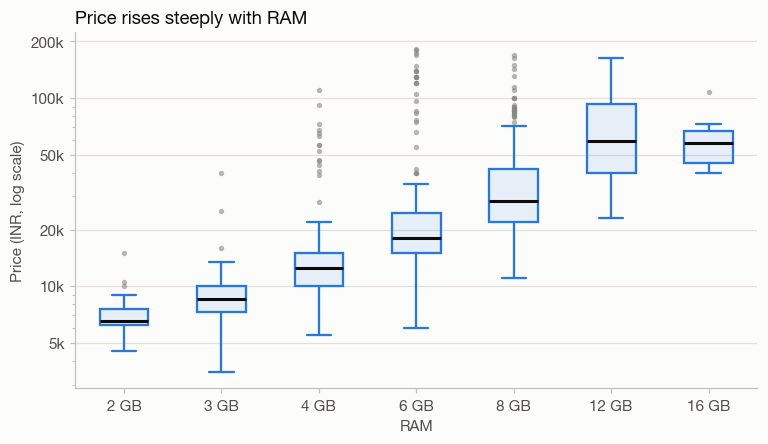

,median price
ram_capacity,
2.00,"6,499.00"
3.00,"8,499.00"
4.00,"12,489.50"
6.00,"17,990.00"
8.00,"28,499.00"
12.00,"58,994.50"
16.00,"57,999.00"


In [30]:
ram_levels = [2, 3, 4, 6, 8, 12, 16]
groups = [df.loc[df.ram_capacity == r, "price"] for r in ram_levels]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.boxplot(groups, **box_style())
ax.set_xticks(range(1, len(ram_levels) + 1), [f"{r} GB" for r in ram_levels])
log_price_axis(ax)
ax.set_ylabel("Price (INR, log scale)")
ax.set_xlabel("RAM")
ax.set_title("Price rises steeply with RAM")
ax.grid(axis="x", visible=False)
save(fig, "06_price_by_ram")
plt.show()

df.groupby("ram_capacity")["price"].median().loc[ram_levels].to_frame("median price")

**c) Faster chips cost more, and 5G phones are at the top**

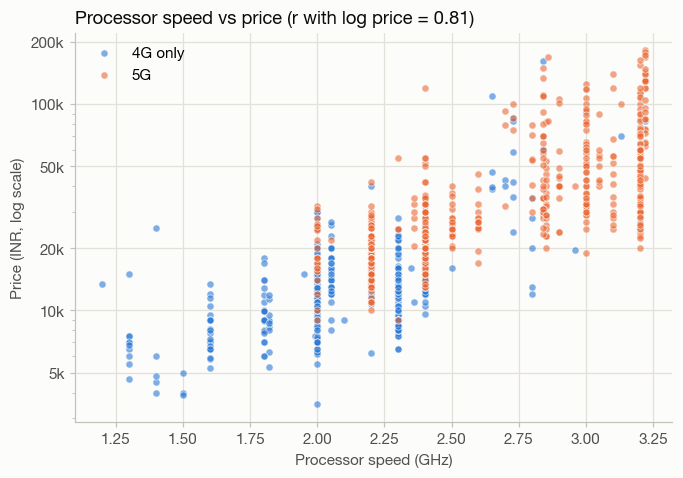

In [31]:
fig, ax = plt.subplots(figsize=(7, 4.6))
for label, value, color in [("4G only", 0, BLUE), ("5G", 1, ORANGE)]:
    s = df[df.has_5g == value]
    ax.scatter(s.processor_speed, s.price, s=22, color=color, alpha=0.6, edgecolors=SURFACE, linewidths=0.6, label=label)
log_price_axis(ax)
r = df["processor_speed"].corr(df["log_price"])
ax.set_title(f"Processor speed vs price (r with log price = {r:.2f})")
ax.set_xlabel("Processor speed (GHz)")
ax.set_ylabel("Price (INR, log scale)")
ax.legend(loc="upper left")
save(fig, "07_speed_vs_price")
plt.show()

**d) 5G depends on the chip family** (a preview of a chi-square test)

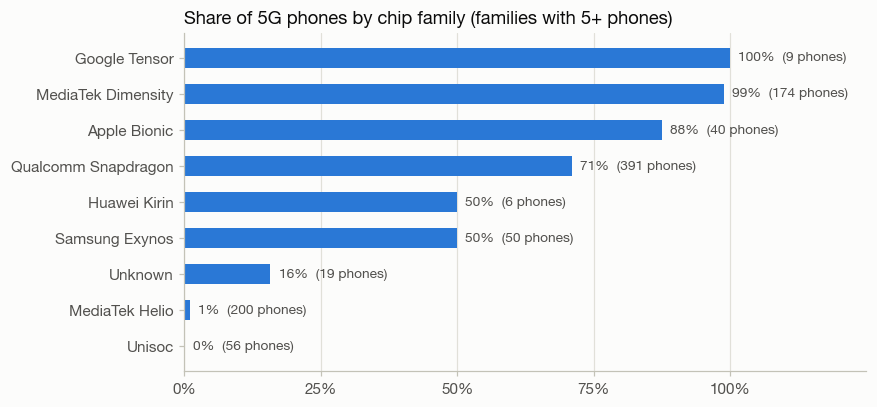

In [32]:
chip_names = {"dimensity": "MediaTek Dimensity", "helio": "MediaTek Helio", "snapdragon": "Qualcomm Snapdragon",
              "exynos": "Samsung Exynos", "bionic": "Apple Bionic", "unisoc": "Unisoc", "google": "Google Tensor",
              "kirin": "Huawei Kirin", "unknown": "Unknown"}
share = df.groupby("processor_brand")["has_5g"].agg(["mean", "size"]).query("size >= 5").sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([chip_names[c] for c in share.index], share["mean"] * 100, height=0.55, color=BLUE)
for y, (v, n) in enumerate(zip(share["mean"] * 100, share["size"])):
    ax.text(v + 1.5, y, f"{v:.0f}%  ({n} phones)", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, 125)
ax.set_xticks([0, 25, 50, 75, 100])
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title("Share of 5G phones by chip family (families with 5+ phones)")
ax.grid(axis="y", visible=False)
save(fig, "08_5g_by_chip_family")
plt.show()

**e) Battery capacity: is 5,000 mAh the standard?** (a preview of a one-sample test)

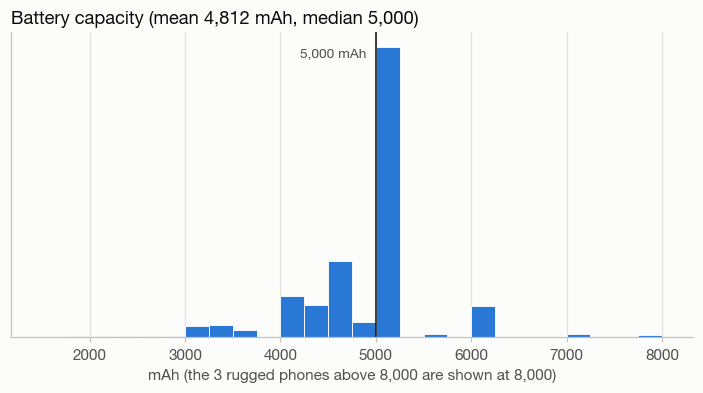

In [33]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(df["battery_capacity"].clip(upper=8000), bins=np.arange(1500, 8250, 250), color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax.axvline(5000, color=INK, linewidth=1)
ax.annotate("5,000 mAh", (5000, ax.get_ylim()[1] * 0.92), xytext=(-6, 0), textcoords="offset points", ha="right", fontsize=9, color=INK2)
ax.set_title(f"Battery capacity (mean {df.battery_capacity.mean():,.0f} mAh, median {df.battery_capacity.median():,.0f})")
ax.set_xlabel(f"mAh (the {(df.battery_capacity > 8000).sum()} rugged phones above 8,000 are shown at 8,000)")
ax.set_yticks([])
ax.grid(axis="y", visible=False)
save(fig, "09_battery_capacity")
plt.show()

**f) 5G phones vs 4G phones: price and rating** (a preview of two-sample tests)

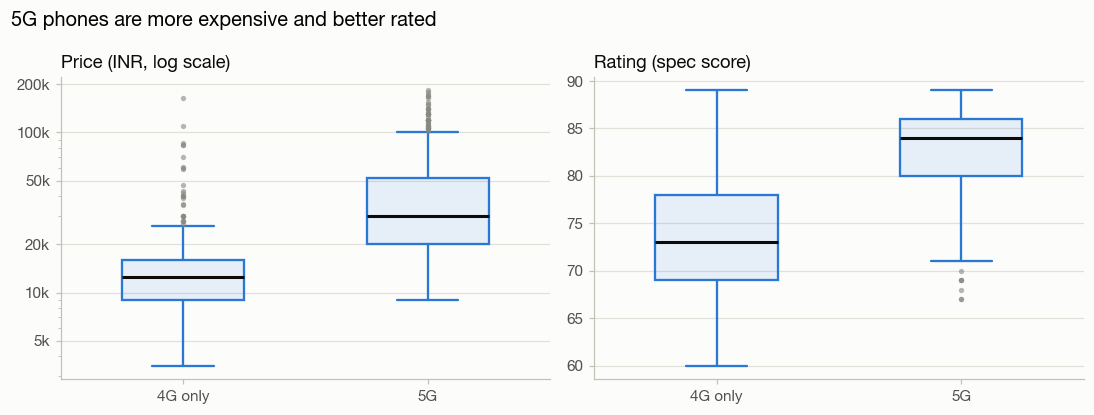

,price,rating
has_5g_label,,
No,"12,499.00",73.00
Yes,"29,990.00",84.00


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, col, title in [(axes[0], "price", "Price (INR, log scale)"), (axes[1], "rating", "Rating (spec score)")]:
    ax.boxplot([df.loc[df.has_5g == 0, col], df.loc[df.has_5g == 1, col]], **box_style())
    ax.set_xticks([1, 2], ["4G only", "5G"])
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
log_price_axis(axes[0])
fig.suptitle("5G phones are more expensive and better rated", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "10_5g_vs_4g")
plt.show()

df.groupby("has_5g_label")[["price", "rating"]].median()

### 7.3 Correlation coefficient (r)
Pearson correlation between the numeric variables and the 0/1 yes/no columns (with a 0/1 variable this is the *point-biserial* correlation). We use `log_price` instead of `price` because the regression in Task 3 will use it.

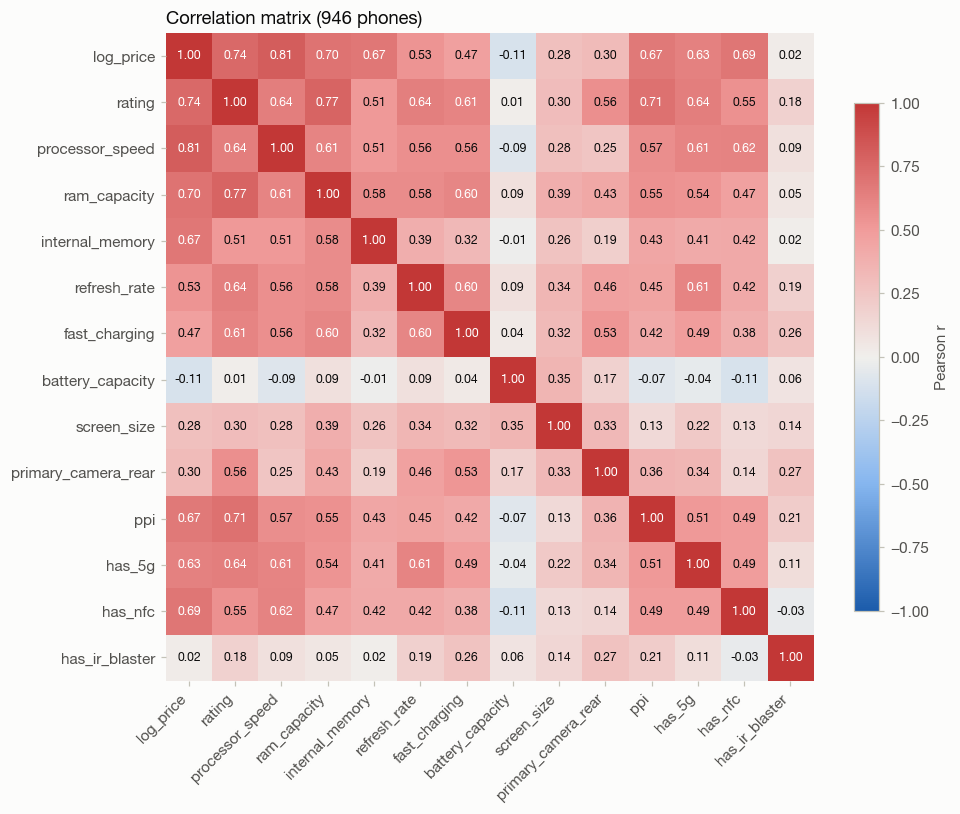

In [35]:
corr_cols = ["log_price", "rating", "processor_speed", "ram_capacity", "internal_memory", "refresh_rate",
             "fast_charging", "battery_capacity", "screen_size", "primary_camera_rear", "ppi",
             "has_5g", "has_nfc", "has_ir_blaster"]
corr = df[corr_cols].corr()

diverging = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#86b6ef", "#f0efec", "#f19c9b", "#c23736"])
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.iloc[i, j]
        label = f"{v:.2f}".replace("-0.00", "0.00")
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.6 else INK)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
ax.set_title(f"Correlation matrix ({len(df)} phones)")
save(fig, "11_correlation_matrix")
plt.show()

In [36]:
corr.round(2) + 0.0          # the same correlation matrix as a table

,log_price,rating,processor_speed,ram_capacity,internal_memory,refresh_rate,fast_charging,battery_capacity,screen_size,primary_camera_rear,ppi,has_5g,has_nfc,has_ir_blaster
log_price,1.00,0.74,0.81,0.70,0.67,0.53,0.47,-0.11,0.28,0.30,0.67,0.63,0.69,0.02
rating,0.74,1.00,0.64,0.77,0.51,0.64,0.61,0.01,0.30,0.56,0.71,0.64,0.55,0.18
processor_speed,0.81,0.64,1.00,0.61,0.51,0.56,0.56,-0.09,0.28,0.25,0.57,0.61,0.62,0.09
ram_capacity,0.70,0.77,0.61,1.00,0.58,0.58,0.60,0.09,0.39,0.43,0.55,0.54,0.47,0.05
internal_memory,0.67,0.51,0.51,0.58,1.00,0.39,0.32,-0.01,0.26,0.19,0.43,0.41,0.42,0.02
refresh_rate,0.53,0.64,0.56,0.58,0.39,1.00,0.60,0.09,0.34,0.46,0.45,0.61,0.42,0.19
fast_charging,0.47,0.61,0.56,0.60,0.32,0.60,1.00,0.04,0.32,0.53,0.42,0.49,0.38,0.26
battery_capacity,-0.11,0.01,-0.09,0.09,-0.01,0.09,0.04,1.00,0.35,0.17,-0.07,-0.04,-0.11,0.06
screen_size,0.28,0.30,0.28,0.39,0.26,0.34,0.32,0.35,1.00,0.33,0.13,0.22,0.13,0.14
primary_camera_rear,0.30,0.56,0.25,0.43,0.19,0.46,0.53,0.17,0.33,1.00,0.36,0.34,0.14,0.27


In [37]:
# Which variables move most with price?
corr["log_price"].drop("log_price").sort_values(key=abs, ascending=False).round(2).to_frame("r with log_price")

,r with log_price
processor_speed,0.81
rating,0.74
ram_capacity,0.70
has_nfc,0.69
internal_memory,0.67
ppi,0.67
has_5g,0.63
refresh_rate,0.53
fast_charging,0.47
primary_camera_rear,0.30


**What the correlations tell us**
- **Processor speed (r = 0.81), rating (0.74) and RAM (0.70)** move most with log price, so they are the main candidates for the **linear regression in Task 3**.
- **NFC (0.69) and 5G (0.63)** also go with higher prices: they are features of more expensive phones.
- **Battery capacity is almost unrelated to price (r = −0.11)**: half of all phones have exactly 5,000 mAh, cheap or expensive.
- The predictors are also correlated **with each other** (e.g. RAM and rating r = 0.77, processor speed and 5G r = 0.61). In Task 3 this *multicollinearity* can make single coefficients unstable, so we'll pick a few strong predictors that measure different things.

## Save the clean dataset
Tasks 2 and 3 start from this file.

In [38]:
df.to_csv(DATA / "smartphones_clean.csv", index=False)
print(f"Saved data/smartphones_clean.csv: {df.shape[0]} phones x {df.shape[1]} columns, {int(df.isna().sum().sum())} missing values")

Saved data/smartphones_clean.csv: 946 phones x 61 columns, 0 missing values


## Summary of Task 1
| | Raw data | Clean data |
|---|---|---|
| Rows | 980 | 946 |
| Columns | 26 | 61 |
| Missing values | 894 (in 10 columns) | 0 |
| Phones that never existed (rumours, concepts) | 27 | 0 |
| Same phone listed twice | 3 | 0 |
| Luxury editions (price not set by specs) | 4 | 0 |
| Inconsistent labels | chip names, 2 brand names, 2 yes/no formats | standardized |
| Outliers | | real ones kept (59 flagged), log(price) added |

**Key insights from the EDA**
1. A typical phone costs **₹19,990 (about €222)**. 5G phones have a median price of **₹29,990 vs ₹12,499** for 4G-only phones.
2. **Price rises steeply with RAM**: the median is ₹6,499 with 2 GB and about ₹59,000 with 12 GB.
3. **56% of phones have 5G**, but it depends on the segment (13% of Budget phones vs 93% of Premium phones) and on the chip (MediaTek Dimensity 99% vs MediaTek Helio 1%).
4. **Half of all phones have exactly 5,000 mAh**, and the mean is 4,812 mAh.
5. **Processor speed is the strongest single predictor of price** (r = 0.81 with log price).

**What comes next**
- *Task 2:* hypothesis tests with α = 0.05: one-sample, two-sample and chi-square tests on battery, price, specs and brands.
- *Task 3:* linear regression for log(price) from the specs, and logistic regression for 5G (Yes/No).